
=== Multivariate Regression ===
Multivariate Mean Squared Error: 0.10913890364526468
Multivariate R² Score: 0.5446016275533394
Coefficients Shape: (2, 4)
Intercepts: [3.60430322 3.00132411]

=== Classification Performance ===
Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1-score (weighted): 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



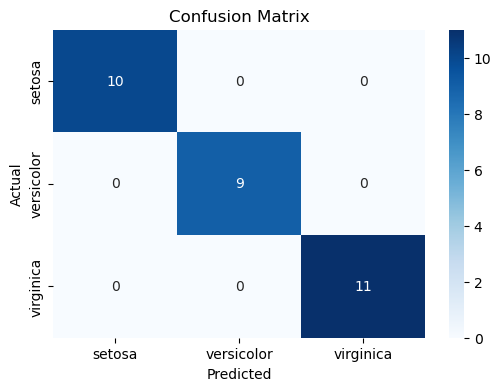

In [2]:
# Step 1: Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sb

# Step 2: Load the dataset
iris = sns.load_dataset('iris')

# -----------------------------
# Part A: Multivariate Regression (Predict sepal_length & sepal_width)
# -----------------------------
print("\n=== Multivariate Regression ===")
# Step 3: Define predictors (X) and multiple targets (Y)
X = iris[['petal_length', 'petal_width', 'species']]
Y = iris[['sepal_length', 'sepal_width']]  # multivariate targets

# Step 4: Preprocessing - OneHotEncode the categorical column 'species'
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['species'])
    ],
    remainder='passthrough'
)

# Step 5: Create pipeline
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Step 6: Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Step 7: Fit model
model.fit(X_train, Y_train)

# Step 8: Predict
Y_pred = model.predict(X_test)

# Step 9: Evaluate regression performance
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Multivariate Mean Squared Error:", mse)
print("Multivariate R² Score:", r2)
print("Coefficients Shape:", model.named_steps['regressor'].coef_.shape)
print("Intercepts:", model.named_steps['regressor'].intercept_)

# -----------------------------
# Part B: Classification (Predict species)
# -----------------------------
print("\n=== Classification Performance ===")
# Features: numeric only for simplicity
X_cls = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_cls = iris['species']

# Train/test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Create pipeline for classification
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))  # Removed multi_class parameter
])

# Train classifier
clf_pipeline.fit(X_train_cls, y_train_cls)

# Predict
y_pred_cls = clf_pipeline.predict(X_test_cls)

# Compute classification metrics
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision (weighted): {precision}")
print(f"Recall (weighted): {recall}")
print(f"F1-score (weighted): {f1}")

# Detailed report
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf_pipeline.classes_, yticklabels=clf_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


=== Multivariate Regression ===
Multivariate Mean Squared Error: 1234768.0185390608
Multivariate R² Score: 0.9010037606906092
Coefficients shape (n_targets x n_features): (2, 23)
Intercepts: [17.1688579   0.81939139]

=== Classification Performance (Predict 'cut') ===
Accuracy: 0.6581
Precision (weighted): 0.6442
Recall (weighted): 0.6581
F1-score (weighted): 0.6321

Classification Report:
               precision    recall  f1-score   support

        Fair       0.76      0.52      0.62       335
        Good       0.60      0.12      0.21      1004
       Ideal       0.72      0.88      0.79      4292
     Premium       0.66      0.73      0.69      2775
   Very Good       0.50      0.43      0.46      2382

    accuracy                           0.66     10788
   macro avg       0.65      0.54      0.55     10788
weighted avg       0.64      0.66      0.63     10788



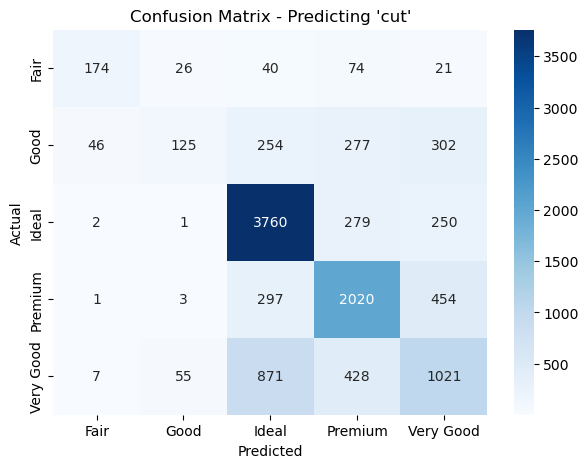

In [3]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sb
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv("C:\\Users\\Somdip.Dey\\Desktop\\Regents_SWE6204\\diamonds.csv")
df.columns = df.columns.str.lower().str.strip()

# ---------------------------
# PART A: MULTIVARIATE REGRESSION
# ---------------------------
print("\n=== Multivariate Regression ===")

# Step 3: Define features and multivariate targets
target_columns = ['price', 'carat']
X = df.drop(columns=target_columns)
Y = df[target_columns]

# Step 4: Define categorical and numerical features
categorical_features = ['cut', 'color', 'clarity']
numerical_features = [col for col in X.columns if col not in categorical_features]

# Step 5: Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# Step 6: Create pipeline with Linear Regression
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Step 7: Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Step 8: Train the model
pipeline.fit(X_train, Y_train)

# Step 9: Predict
Y_pred = pipeline.predict(X_test)

# Step 10: Evaluate regression performance
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Multivariate Mean Squared Error:", mse)
print("Multivariate R² Score:", r2)
print("Coefficients shape (n_targets x n_features):", pipeline.named_steps['regressor'].coef_.shape)
print("Intercepts:", pipeline.named_steps['regressor'].intercept_)

# ---------------------------
# PART B: CLASSIFICATION TASK (Predict 'cut')
# ---------------------------
print("\n=== Classification Performance (Predict 'cut') ===")

# Classification: Use numeric features only for simplicity
X_cls = df[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']]
y_cls = df['cut']  # target for classification

# Train/test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Create classification pipeline (Logistic Regression)
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))  # Removed multi_class param to avoid warning
])

# Train classifier
clf_pipeline.fit(X_train_cls, y_train_cls)

# Predict
y_pred_cls = clf_pipeline.predict(X_test_cls)

# Compute metrics
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls))

# Confusion Matrix visualization
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(7,5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf_pipeline.classes_, yticklabels=clf_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Predicting 'cut'")
plt.show()

The classification performance for predicting cut is only moderate because:

cut is categorical with imbalanced classes (Ideal and Premium dominate).

We used a simple Logistic Regression on numeric features only, ignoring categorical relationships.

No feature engineering or hyperparameter tuning was done.

✅ How to Improve Performance:
Include more features:

Currently, classification uses numeric columns only (carat, depth, table, x, y, z, price).

Use color and clarity as categorical predictors (with OneHotEncoding).

Handle class imbalance:

Use class_weight='balanced' in Logistic Regression or switch to a tree-based model like RandomForestClassifier.

Hyperparameter tuning:

 - Use GridSearchCV for finding the best model parameters.

 - Scale numeric features (already done).


=== Multivariate Regression ===
Multivariate Mean Squared Error: 1234768.0185390608
Multivariate R² Score: 0.9010037606906092
Coefficients shape: (2, 23)
Intercepts: [17.1688579   0.81939139]

=== Improved Classification Performance (Predict 'cut') ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Accuracy: 0.7745
Precision (weighted): 0.7662
Recall (weighted): 0.7745
F1-score (weighted): 0.7649

Classification Report:
               precision    recall  f1-score   support

        Fair       0.90      0.90      0.90       335
        Good       0.74      0.72      0.73      1004
       Ideal       0.83      0.92      0.87      4292
     Premium       0.74      0.82      0.78      2775
   Very Good       0.68      0.47      0.56      2382

    accuracy                           0.77     10788
   macro avg       0.78      0.76      0.77     10788
weighte

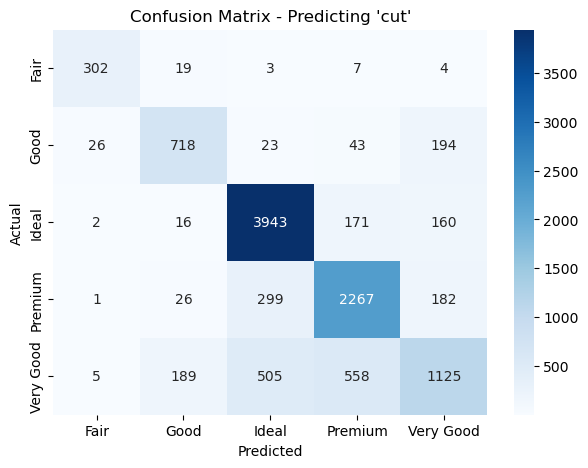

In [5]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Step 2: Load dataset
df = pd.read_csv("C:\\Users\\Somdip.Dey\\Desktop\\Regents_SWE6204\\diamonds.csv")
df.columns = df.columns.str.lower().str.strip()

# ---------------------------
# PART A: MULTIVARIATE REGRESSION
# ---------------------------
print("\n=== Multivariate Regression ===")

# Features and targets
target_columns = ['price', 'carat']
X = df.drop(columns=target_columns)
Y = df[target_columns]

categorical_features = ['cut', 'color', 'clarity']
numerical_features = [col for col in X.columns if col not in categorical_features]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# Pipeline for regression
reg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Split and train
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
reg_pipeline.fit(X_train, Y_train)

# Predict & evaluate regression
Y_pred = reg_pipeline.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Multivariate Mean Squared Error:", mse)
print("Multivariate R² Score:", r2)
print("Coefficients shape:", reg_pipeline.named_steps['regressor'].coef_.shape)
print("Intercepts:", reg_pipeline.named_steps['regressor'].intercept_)

# ---------------------------
# PART B: CLASSIFICATION TASK (Improved - Predict 'cut')
# ---------------------------
print("\n=== Improved Classification Performance (Predict 'cut') ===")

# Define X, y for classification
X_cls = df.drop(columns=['cut'])  # use all features except 'cut'
y_cls = df['cut']

# Updated categorical and numeric features for classification
categorical_cls = ['color', 'clarity']  # cut is target, so exclude it
numerical_cls = [col for col in X_cls.columns if col not in categorical_cls]

# Preprocessor for classification
cls_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cls),
        ('num', StandardScaler(), numerical_cls)
    ]
)

# RandomForest pipeline
clf_pipeline = Pipeline([
    ('preprocessing', cls_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Train/test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(clf_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_cls, y_train_cls)

best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# Predict and evaluate
y_pred_cls = best_model.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_pred_cls, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")

# Classification report
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls))

# Confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(7, 5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.named_steps['classifier'].classes_,
           yticklabels=best_model.named_steps['classifier'].classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Predicting 'cut'")
plt.show()